# Naive Classification Approach: Predict Cortical Layer from Raw Time Series

Goal: build a simple baseline classifier where each neuron trial trace is used directly as input features.

What this notebook does:
- Builds a dataset of neuron trial traces from matched V1 excitatory neurons
- Uses raw (z-scored) time series values as model inputs
- Trains naive baseline classifiers
- Reports accuracy, balanced accuracy, macro-F1, and confusion matrix

In [3]:
%reload_ext autoreload
%autoreload 2

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../../').resolve()
print(f'Workspace root: {ROOT}')

Workspace root: C:\Users\tomma\Desktop\NEUROSCIENCE


In [4]:
# 1) Load matched structural metadata and keep excitatory V1 neurons with functional matches.
cleaner = mic.MicronsDataCleaner(datadir='../../data', version=1718, download_policy='minimum')
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1'
).copy()

# Detect neuron index column used by the functional array.
# Some versions expose this as functional_unit_id rather than unit_id.
unit_id_col = None
for col_name in [
    'functional_unit_id',
    'unit_id',
    'index',
    'neuron_idx',
    'neuron_id',
]:
    if col_name in matched.columns:
        unit_id_col = col_name
        break

if unit_id_col is None:
    available = ', '.join(matched.columns.astype(str).tolist())
    raise ValueError(
        'No usable neuron index column found in matched table. '
        f'Available columns: {available}'
    )

print(f'Matched neurons: {len(matched)}')
print(f'Using unit id column: {unit_id_col}')
print('Layer counts:')
print(matched['layer'].value_counts(dropna=False).sort_index().to_string())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 92931.43it/s]


Matched neurons: 13044
Using unit id column: functional_unit_id
Layer counts:
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478


In [5]:
# 2) Open functional H5 and select available session/scan keys.
candidate_paths = [
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5.h5',
    ROOT / 'microns.h5',
]

existing = [p for p in candidate_paths if p.exists()]
if not existing:
    raise FileNotFoundError('No functional H5 found in expected locations.')

functional_path = existing[0]
print(f'Using functional file: {functional_path}')

funcreader = mic.MicronsFunctionalReader(datadir=str(ROOT / 'data'), path=str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

# Parse keys like 'SESSION_SCAN'.
scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key']).sort_values(['session', 'scan_idx'])
print(f'Available session/scan keys: {len(scan_df)}')
scan_df.head(10)

Using functional file: C:\Users\tomma\Desktop\NEUROSCIENCE\data\functional\microns_functional.h5
Available session/scan keys: 14


,session,scan_idx,key
0,4,7,4_7
1,5,6,5_6
2,5,7,5_7
3,6,2,6_2
4,6,4,6_4
5,6,6,6_6
6,6,7,6_7
7,7,3,7_3
8,7,4,7_4
9,7,5,7_5


In [21]:
# 3) Build a naive dataset using all usable session/scan pairs.
# The same neuron can appear multiple times across trials and scans, which is acceptable for this naive baseline.
MAX_TRIALS_PER_SCAN = 8
MAX_SAMPLES_PER_LAYER = None
MIN_TRACE_LEN = 60
MAX_FEATURE_LEN = 300
EXCLUDE_LAYERS = {'L1'}

records = []
layer_counter = {}

# Rebuild scan candidates from the H5 keys on every run so rerunning this cell does not reuse a previously filtered scan_df.
available_scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) != 2:
        continue
    try:
        available_scan_rows.append((int(parts[0]), int(parts[1]), k))
    except ValueError:
        continue

available_scan_df = pd.DataFrame(
    available_scan_rows, columns=['session', 'scan_idx', 'key']
).sort_values(['session', 'scan_idx']).reset_index(drop=True)

# Use every matched session/scan pair that also exists in the functional file.
matched_scans = matched[['session', 'scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session'] = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)
scan_candidates = available_scan_df.merge(matched_scans, on=['session', 'scan_idx'], how='inner')
scan_candidates = scan_candidates.sort_values(['session', 'scan_idx']).reset_index(drop=True)

print(f'Candidate session/scan pairs in matched + functional data: {len(scan_candidates)}')

used_scans = 0
for _, row in scan_candidates.iterrows():
    session = int(row['session'])
    scan_idx = int(row['scan_idx'])
    key = row['key']

    session_neurons = matched[(matched['session'] == session) & (matched['scan_idx'] == scan_idx)].copy()
    session_neurons = session_neurons.dropna(subset=[unit_id_col, 'layer'])
    session_neurons['layer'] = session_neurons['layer'].astype(str)
    session_neurons = session_neurons[~session_neurons['layer'].isin(EXCLUDE_LAYERS)]
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    # functional_unit_id matches the values in meta/unit_ids, not necessarily row positions.
    unit_ids = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(unit_id): idx for idx, unit_id in enumerate(unit_ids)}

    n_trials = len(hashes) if MAX_TRIALS_PER_SCAN is None else min(len(hashes), MAX_TRIALS_PER_SCAN)
    used_scans += 1

    for t in range(n_trials):
        td = funcreader.get_trial(key, t)
        if td is None:
            continue

        responses = td['responses']

        for _, nr in session_neurons.iterrows():
            layer = str(nr['layer'])
            layer_counter.setdefault(layer, 0)
            if MAX_SAMPLES_PER_LAYER is not None and layer_counter[layer] >= MAX_SAMPLES_PER_LAYER:
                continue

            functional_unit_id = int(nr[unit_id_col])
            row_idx = unit_id_to_row.get(functional_unit_id)
            if row_idx is None or row_idx < 0 or row_idx >= responses.shape[0]:
                continue

            trace = np.asarray(responses[row_idx, :], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue

            records.append({
                'layer': layer,
                'trace': trace,
                'session': session,
                'scan_idx': scan_idx,
                'trial_idx': t,
                'unit_id': functional_unit_id,
            })
            layer_counter[layer] += 1

print(f'Used session/scan pairs: {used_scans}')
print(f'Total raw samples collected: {len(records)}')
print('Samples by layer (after exclusions):')
raw_counts = pd.Series([r['layer'] for r in records]).value_counts().sort_index()
print(raw_counts.to_string())

if len(records) < 100:
    raise ValueError('Too few samples collected across all session/scan pairs.')

target_len = min(MAX_FEATURE_LEN, min(len(r['trace']) for r in records))
print(f'Using trace length: {target_len} timepoints per sample')
missing_key_layers = [l for l in ['L2/3', 'L4', 'L5', 'L6'] if l not in raw_counts.index]
if missing_key_layers:
    print(f'Note: missing layers in collected samples: {missing_key_layers}')
else:
    print('All target layers L2/3, L4, L5, and L6 are present in the collected dataset.')

Candidate session/scan pairs in matched + functional data: 14
Used session/scan pairs: 14
Total raw samples collected: 99384
Samples by layer (after exclusions):
L2/3    48872
L4      29984
L5      16936
L6       3592
Using trace length: 75 timepoints per sample
All target layers L2/3, L4, L5, and L6 are present in the collected dataset.


In [22]:
# 4) Create feature matrix X and labels y.
X = []
y = []

for r in records:
    trace = r['trace'][:target_len]
    # Per-sample z-score keeps shape information while reducing scale effects.
    trace = (trace - trace.mean()) / (trace.std() + 1e-8)
    X.append(trace)
    y.append(r['layer'])

X = np.asarray(X)
y = np.asarray(y)

# Explicitly remove L1 from the modeling dataset.
mask_non_l1 = y != 'L1'
X = X[mask_non_l1]
y = y[mask_non_l1]

# Drop very rare classes that break stable stratified splitting.
counts = pd.Series(y).value_counts()
keep_layers = counts[counts >= 20].index.tolist()
dropped_rare_layers = sorted(set(counts.index) - set(keep_layers))
mask_keep = np.isin(y, keep_layers)
X = X[mask_keep]
y = y[mask_keep]

if len(np.unique(y)) < 2:
    raise ValueError(
        'Need at least 2 layers after filtering. '
        f'Current counts: {pd.Series(y).value_counts().to_dict()}'
    )

enc = LabelEncoder()
y_enc = enc.fit_transform(y)

print(f'Final dataset shape: X={X.shape}, y={y.shape}')
print('Kept layers and counts:')
print(pd.Series(y).value_counts().sort_index().to_string())
if dropped_rare_layers:
    print(f'Dropped for rarity (<20 samples): {dropped_rare_layers}')

Final dataset shape: X=(99384, 75), y=(99384,)
Kept layers and counts:
L2/3    48872
L4      29984
L5      16936
L6       3592


In [23]:
# 5) Train/test split and naive models.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)

models = {
    'Dummy-most-frequent': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': LogisticRegression(max_iter=600, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
}

rows = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro')
    })
    fitted_models[name] = model

results_df = pd.DataFrame(rows).sort_values('balanced_accuracy', ascending=False)
results_df

,model,accuracy,balanced_accuracy,macro_f1
1,LogisticRegression,0.234726,0.272783,0.215336
2,RandomForest,0.483659,0.255667,0.200478
0,Dummy-most-frequent,0.491749,0.250000,0.164823


Best model: LogisticRegression

Classification report (test set):
              precision    recall  f1-score   support

        L2/3       0.51      0.21      0.29     12218
          L4       0.32      0.27      0.29      7496
          L5       0.18      0.21      0.20      4234
          L6       0.04      0.40      0.08       898

    accuracy                           0.23     24846
   macro avg       0.26      0.27      0.22     24846
weighted avg       0.38      0.23      0.27     24846



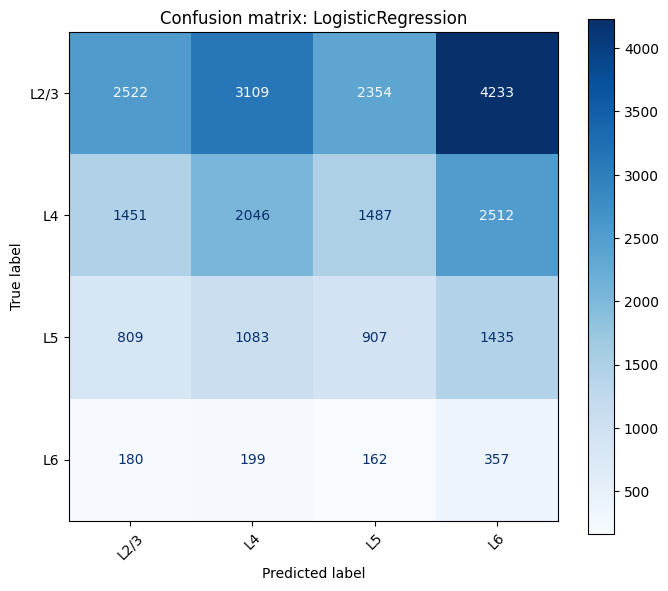

In [24]:
# 6) Detailed report + confusion matrix for best model by balanced accuracy.
best_model_name = results_df.iloc[0]['model']
best_model = fitted_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f'Best model: {best_model_name}')
print('\nClassification report (test set):')
print(classification_report(y_test, y_pred_best, target_names=enc.classes_))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=enc.classes_,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Confusion matrix: {best_model_name}')
plt.tight_layout()
plt.show()

## Interpretation

This is a deliberately naive baseline. The dataset now aggregates samples across all usable session/scan pairs, so the same neuron can contribute multiple labeled examples across different trials and recording contexts.

That makes the dataset larger and brings in more layers, but it also makes the task easier in a slightly unrealistic way because train/test splits can contain repeated measurements of the same neuron.

Natural next upgrades:
- Split by neuron identity so the same neuron never appears in both train and test
- Split by session/scan to test generalization to unseen experiments
- Add simple engineered features (peak, latency, power in frequency bands)
- Average by neuron across trials before classification
- Use stronger temporal models (1D-CNN / RNN)